<div style="background-color: #6EC1E4; color: white; padding: 20px; text-align: center; border-radius: 10px;">
    <div style="font-size: 36px; margin-bottom: 10px; font-weight: bold;">Supervised Learning Assignment 1</div>
    <h1 style="font-size: 28px; margin-top: 5px;">Machine Learning Algorithm to Predict Customer Churn</h1>
</div>

<br>

**Student:** Netanel Farhi  
**Task:** Option B - Telco Customer Churn Classification  

This notebook builds the project end-to-end: business framing, data checks, cleaning, feature engineering, leakage checks, multicollinearity check, preprocessing, baseline, model training, evaluation, error analysis, feature importance, stability check, and report generation.

## 0. Business framing

The business problem is customer churn prediction.  
The company wants to identify customers who are likely to leave, so the retention team can focus on the right customers before it is too late.

**Target:** `Churn = Yes`  
**Positive class:** customer churned  
**Primary model-selection metric:** ROC-AUC  
**Operating metric:** recall / precision at the selected threshold

I use ROC-AUC to compare models because it evaluates ranking quality across thresholds.  
After choosing the model, I choose a decision threshold based on the business tradeoff between false positives and false negatives.

In [1]:
# Core imports
import os
import sys
import subprocess
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_score,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

## 1. Load the dataset

The dataset is expected to be the Telco Customer Churn CSV from Kaggle.  
The safest option for submission is to keep `WA_Fn-UseC_-Telco-Customer-Churn.csv` in the same folder as this notebook.

In [2]:
# Load the Telco Customer Churn dataset
# Option 1: put the CSV next to this notebook.
# Option 2: if kagglehub is available, the notebook can download it.

def install_and_import_kagglehub():
    try:
        import kagglehub
        return kagglehub
    except ModuleNotFoundError:
        print("kagglehub is not installed. Installing it now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub
        return kagglehub

def find_telco_csv():
    search_roots = [Path("."), Path.cwd(), Path("/mnt/data")]
    possible_names = [
        "WA_Fn-UseC_-Telco-Customer-Churn.csv",
        "telco_churn.csv",
        "Telco-Customer-Churn.csv",
    ]

    # Search exact and likely names first
    for root in search_roots:
        for name in possible_names:
            file_path = root / name
            if file_path.exists():
                return file_path

        for file_path in root.glob("*.csv"):
            lower_name = file_path.name.lower()
            if "telco" in lower_name or "churn" in lower_name:
                return file_path

    # Fallback: download using kagglehub
    try:
        kagglehub = install_and_import_kagglehub()
        dataset_path = Path(kagglehub.dataset_download("blastchar/telco-customer-churn"))
        csv_files = list(dataset_path.glob("*.csv"))

        if not csv_files:
            raise FileNotFoundError("No CSV file was found in the Kaggle dataset folder.")

        return csv_files[0]
    except Exception as e:
        raise FileNotFoundError(
            "Could not find or download the Telco CSV. "
            "Please place WA_Fn-UseC_-Telco-Customer-Churn.csv next to this notebook."
        ) from e

csv_path = find_telco_csv()
print("Dataset file:", csv_path)

df_raw = pd.read_csv(csv_path)
print("Raw shape:", df_raw.shape)
df_raw.head()

Dataset file: C:\Users\netaf\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv
Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data understanding

Before modeling, I check the structure of the data: data types, missing values, duplicates, unique values, and the target distribution.  
This step is important because a model can only be as good as the data pipeline behind it.

In [3]:
# Basic structure
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Missing values, data types, and unique values
data_quality = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique_values": df_raw.nunique(dropna=False),
}).sort_values(["missing_count", "unique_values"], ascending=[False, False])

data_quality

,dtype,missing_count,missing_pct,unique_values
customerID,object,0,0.0,7043
TotalCharges,object,0,0.0,6531
MonthlyCharges,float64,0,0.0,1585
tenure,int64,0,0.0,73
PaymentMethod,object,0,0.0,4
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3
OnlineBackup,object,0,0.0,3
DeviceProtection,object,0,0.0,3


In [5]:
# Duplicate check
duplicate_rows = df_raw.duplicated().sum()
duplicate_customer_ids = df_raw["customerID"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate rows: 0
Duplicate customer IDs: 0


In [6]:
# Target distribution
target_dist = (
    df_raw["Churn"]
    .value_counts(normalize=True)
    .rename("share")
    .to_frame()
    .assign(count=df_raw["Churn"].value_counts())
)
target_dist

,share,count
Churn,,
No,0.73463,5174
Yes,0.26537,1869


In [7]:
# Quick look at numeric fields before cleaning
df_raw[["tenure", "MonthlyCharges", "TotalCharges"]].head(10)

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
5,8,99.65,820.5
6,22,89.10,1949.4
7,10,29.75,301.9
8,28,104.80,3046.05
9,62,56.15,3487.95


## 3. Data cleaning and type handling

`TotalCharges` appears as an object, but it should be numeric.  
I convert it using `pd.to_numeric`. Rows that become missing after conversion are removed, because they are very few and do not justify imputation.

I keep `SeniorCitizen` as a binary 0/1 feature.  
It already has a valid numeric indicator format, so converting it to Yes/No and then one-hot encoding it would not add information.

In [8]:
df = df_raw.copy()

# Convert TotalCharges from text to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())

# Inspect the rows with missing TotalCharges
df[df["TotalCharges"].isna()]

Missing TotalCharges after conversion: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [9]:
# Drop rows with missing TotalCharges
rows_before = len(df)
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
rows_after = len(df)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_before - rows_after)

# SeniorCitizen is already a binary 0/1 indicator, so I keep it numeric.

# Binary target
df["churn"] = (df["Churn"] == "Yes").astype(int)

df.info()

Rows before: 7043
Rows after: 7032
Rows removed: 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   obj

In [10]:
# Check missing values again after cleaning
clean_quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=False),
}).sort_values(["missing_count", "unique_values"], ascending=[False, False])

clean_quality

,dtype,missing_count,missing_pct,unique_values
customerID,object,0,0.0,7032
TotalCharges,float64,0,0.0,6530
MonthlyCharges,float64,0,0.0,1584
tenure,int64,0,0.0,72
PaymentMethod,object,0,0.0,4
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3
OnlineBackup,object,0,0.0,3
DeviceProtection,object,0,0.0,3


## 3.1 Data validation

Before modeling, I check for impossible values.  
This is important because unusual values can create misleading patterns and hurt the model.

In [11]:
validation_checks = pd.DataFrame({
    "check": [
        "tenure below 0",
        "tenure above 72",
        "MonthlyCharges below 0",
        "TotalCharges below 0",
        "SeniorCitizen not in {0, 1}",
    ],
    "violations": [
        (df["tenure"] < 0).sum(),
        (df["tenure"] > 72).sum(),
        (df["MonthlyCharges"] < 0).sum(),
        (df["TotalCharges"] < 0).sum(),
        (~df["SeniorCitizen"].isin([0, 1])).sum(),
    ],
})

validation_checks

,check,violations
0,tenure below 0,0
1,tenure above 72,0
2,MonthlyCharges below 0,0
3,TotalCharges below 0,0
4,"SeniorCitizen not in {0, 1}",0


In [12]:
# Quick numeric range check
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


## 4. EDA

I keep the EDA focused on four simple views that explain the main churn patterns:  
target balance, contract type, customer tenure, and monthly charges.

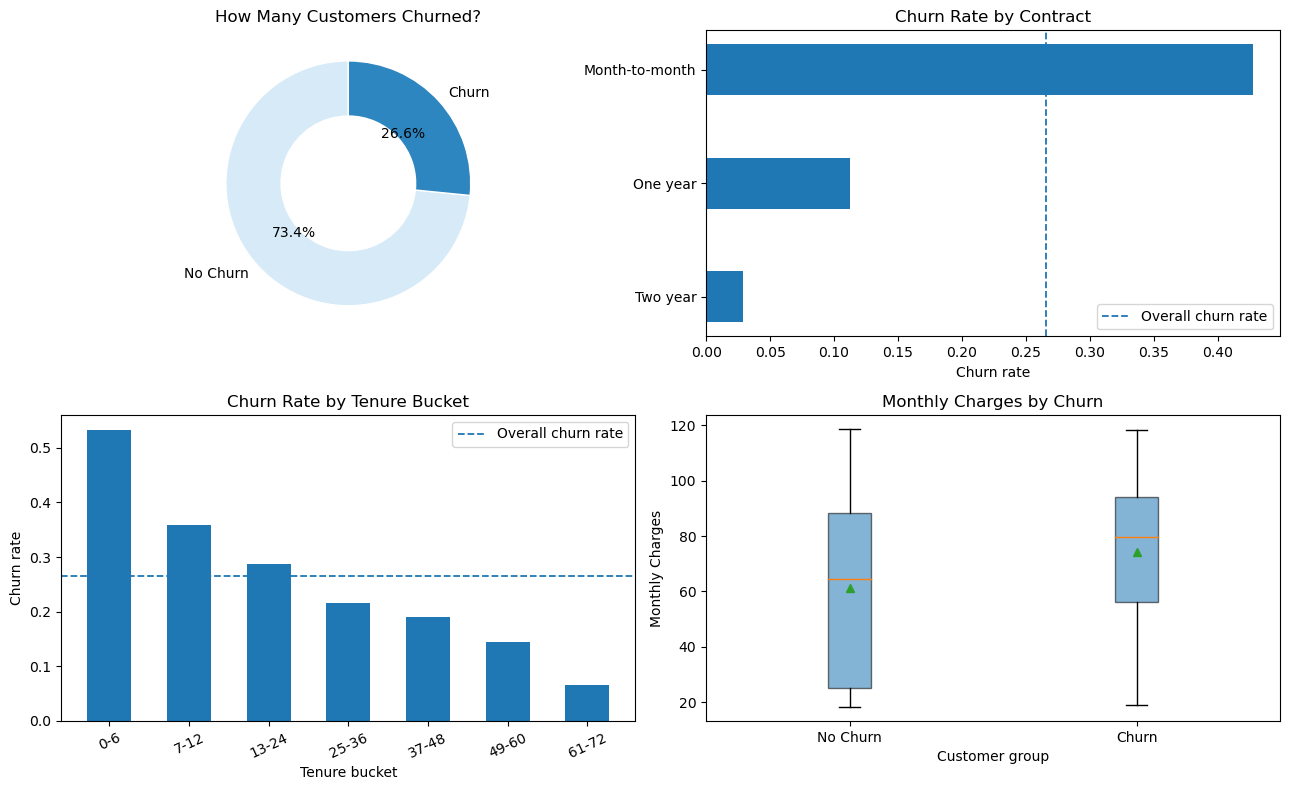

In [13]:
# Four EDA plots in one output
overall_churn_rate = df["churn"].mean()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1) Donut chart: target distribution
churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"])

axes[0, 0].pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    colors=["#D6EAF8", "#2E86C1"],
    wedgeprops={"width": 0.45, "edgecolor": "white"},
    textprops={"fontsize": 10},
)
axes[0, 0].set_title("How Many Customers Churned?")

# 2) Churn rate by contract
contract_rate = df.groupby("Contract")["churn"].mean().sort_values()

axes[0, 1].barh(
    contract_rate.index.astype(str),
    contract_rate.values,
    height=0.45
)
axes[0, 1].axvline(
    overall_churn_rate,
    linestyle="--",
    linewidth=1.3,
    label="Overall churn rate"
)
axes[0, 1].set_title("Churn Rate by Contract")
axes[0, 1].set_xlabel("Churn rate")
axes[0, 1].legend()

# 3) Churn rate by tenure bucket
df["tenure_bucket_eda"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 36, 48, 60, 72],
    labels=["0-6", "7-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)

tenure_rate = (
    df.groupby("tenure_bucket_eda", observed=False)["churn"]
    .mean()
)

axes[1, 0].bar(
    tenure_rate.index.astype(str),
    tenure_rate.values,
    width=0.55
)
axes[1, 0].axhline(
    overall_churn_rate,
    linestyle="--",
    linewidth=1.3,
    label="Overall churn rate"
)
axes[1, 0].set_title("Churn Rate by Tenure Bucket")
axes[1, 0].set_xlabel("Tenure bucket")
axes[1, 0].set_ylabel("Churn rate")
axes[1, 0].tick_params(axis="x", rotation=25)
axes[1, 0].legend()

# 4) Monthly charges by churn
monthly_no = df.loc[df["Churn"] == "No", "MonthlyCharges"]
monthly_yes = df.loc[df["Churn"] == "Yes", "MonthlyCharges"]

box = axes[1, 1].boxplot(
    [monthly_no, monthly_yes],
    labels=["No Churn", "Churn"],
    patch_artist=True,
    showmeans=True
)

for patch in box["boxes"]:
    patch.set_alpha(0.55)

axes[1, 1].grid(False)
axes[1, 1].set_title("Monthly Charges by Churn")
axes[1, 1].set_xlabel("Customer group")
axes[1, 1].set_ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

**Target distribution:** Most customers did not churn. This creates an imbalanced target, so accuracy alone can be misleading. A model that predicts mostly “No Churn” can look accurate but still fail to identify customers who actually leave.

**Contract:** Month-to-month customers have a much higher churn rate than customers with one-year or two-year contracts. This makes sense because longer contracts usually indicate stronger customer commitment.

**Tenure bucket:** Churn is higher among newer customers and decreases as tenure increases. This suggests that the first months after joining are the highest-risk period.

**Monthly charges:** Customers who churn tend to have higher monthly charges. This may indicate that expensive plans are connected to higher price sensitivity or dissatisfaction.

## 5. Feature engineering

I keep feature engineering simple.  
I create a few business features for analysis, but I avoid duplicated signals in the final model.

The final model keeps the original business columns and removes engineered features that duplicate existing information.

In [14]:
df_model = df.copy()

# EDA feature: tenure bucket
df_model["tenure_group"] = pd.cut(
    df_model["tenure"],
    bins=[-1, 6, 12, 24, 36, 48, 60, 72],
    labels=["0-6", "7-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
).astype(str)

# EDA feature: safe average charge per tenure month
df_model["avg_charge_per_tenure_month"] = (
    df_model["TotalCharges"] / df_model["tenure"].replace(0, np.nan)
)
df_model["avg_charge_per_tenure_month"] = df_model["avg_charge_per_tenure_month"].fillna(
    df_model["MonthlyCharges"]
)

# EDA features based on business logic
df_model["has_internet"] = np.where(df_model["InternetService"] == "No", "No", "Yes")
df_model["is_month_to_month"] = np.where(df_model["Contract"] == "Month-to-month", "Yes", "No")

service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
df_model["num_protection_services"] = (df_model[service_cols] == "Yes").sum(axis=1)

df_model[[
    "tenure", "tenure_group", "MonthlyCharges", "TotalCharges",
    "avg_charge_per_tenure_month", "has_internet",
    "is_month_to_month", "num_protection_services", "churn"
]].head()

,tenure,tenure_group,MonthlyCharges,TotalCharges,avg_charge_per_tenure_month,has_internet,is_month_to_month,num_protection_services,churn
0,1,0-6,29.85,29.85,29.850000,Yes,Yes,1,0
1,34,25-36,56.95,1889.50,55.573529,Yes,No,2,0
2,2,0-6,53.85,108.15,54.075000,Yes,Yes,2,1
3,45,37-48,42.30,1840.75,40.905556,Yes,No,3,0
4,2,0-6,70.70,151.65,75.825000,Yes,Yes,0,1


## 6. Define target and remove leakage

I remove:
- `customerID`: identifier, not a real predictive business signal.
- `Churn`: the raw target.
- `churn`: the binary target copy.

Everything else is treated as a possible feature and then checked through the preprocessing pipeline.

In [15]:
# Final model features:
# Keep raw business features and avoid duplicated engineered features.
duplicated_engineered_features = [
    "tenure_group",
    "avg_charge_per_tenure_month",
    "has_internet",
    "is_month_to_month",
    "num_protection_services",
    "tenure_bucket_eda",
]

leakage_columns = ["customerID", "Churn", "churn", "tenure_group_eda"]

X = df_model.drop(columns=leakage_columns + duplicated_engineered_features, errors="ignore")
y = df_model["churn"]

print("X shape:", X.shape)
print("y mean / churn rate:", round(y.mean(), 3))

X.head()

X shape: (7032, 19)
y mean / churn rate: 0.266


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


## 7. Honest train-test split

For this option there is no date column, so I use a stratified random split.  
The test set is kept locked until the final evaluation.  
All checks that can influence modeling are done on the training set only.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 3))
print("Test churn rate:", round(y_test.mean(), 3))

Train shape: (5625, 19)
Test shape: (1407, 19)
Train churn rate: 0.266
Test churn rate: 0.266


## 8. Multicollinearity check

I check multicollinearity only on the training data.  
This matters mainly for Logistic Regression, because highly correlated numeric features can make coefficients unstable.

I use a correlation threshold of **0.80**.  
This is a conservative rule: it removes only very strong overlap, not moderate relationships.

In this dataset:
- `tenure` and `TotalCharges` are strongly correlated, which makes sense because total charges grow over time.
- `MonthlyCharges` and `TotalCharges` are related too, but the correlation is weaker.

So the most reasonable choice is usually to remove `TotalCharges` when the threshold is 0.80, while keeping `MonthlyCharges`.

In [17]:
# Detect numeric and categorical features after the split
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
# Correlation check for numeric features on training data only
corr_threshold = 0.80

numeric_corr = X_train[numeric_features].corr().abs()

upper_triangle = numeric_corr.where(
    np.triu(np.ones(numeric_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .query("abs_corr >= @corr_threshold")
    .sort_values("abs_corr", ascending=False)
)

high_corr_pairs

,feature_1,feature_2,abs_corr
4,tenure,TotalCharges,0.827181


**Interpretation:**  
If the threshold is set to **0.80**, only `tenure` and `TotalCharges` are treated as strongly collinear.  
If the threshold is lowered too much, for example to 0.60, the model may remove useful information too aggressively.  
For this task, **0.80 is a good balance**.

In [19]:
# Drop the more redundant numeric feature when high correlation is found.
# I use average correlation to the other numeric fields as a simple rule.
features_to_drop_corr = []

for _, row in high_corr_pairs.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]

    if f1 in features_to_drop_corr or f2 in features_to_drop_corr:
        continue

    mean_corr_f1 = numeric_corr[f1].drop(index=f1).mean()
    mean_corr_f2 = numeric_corr[f2].drop(index=f2).mean()

    drop_feature = f1 if mean_corr_f1 >= mean_corr_f2 else f2
    features_to_drop_corr.append(drop_feature)

numeric_features_model = [c for c in numeric_features if c not in features_to_drop_corr]

print("Correlation threshold:", corr_threshold)
print("Numeric features removed due to high correlation:", features_to_drop_corr)
print("Numeric features kept:", numeric_features_model)

Correlation threshold: 0.8
Numeric features removed due to high correlation: ['TotalCharges']
Numeric features kept: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [20]:
# VIF-like check without statsmodels
# VIF = 1 / (1 - R²), where each numeric feature is predicted by the other numeric features.
# This is used as a diagnostic, not as a blind deletion rule.

def calculate_vif_like_table(data, columns):
    rows = []

    if len(columns) < 2:
        return pd.DataFrame(columns=["feature", "vif_like"])

    scaled = StandardScaler().fit_transform(data[columns])

    for idx, col in enumerate(columns):
        y_col = scaled[:, idx]
        x_other = np.delete(scaled, idx, axis=1)

        r2 = LinearRegression().fit(x_other, y_col).score(x_other, y_col)
        vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)

        rows.append({"feature": col, "vif_like": vif})

    return pd.DataFrame(rows).sort_values("vif_like", ascending=False)

vif_before = calculate_vif_like_table(X_train, numeric_features)
vif_after = calculate_vif_like_table(X_train, numeric_features_model)

print("VIF-like table before removing correlated numeric features:")
display(vif_before)

print("VIF-like table after removing correlated numeric features:")
display(vif_after)

VIF-like table before removing correlated numeric features:


,feature,vif_like
3,TotalCharges,9.626721
1,tenure,5.887990
2,MonthlyCharges,3.325204
0,SeniorCitizen,1.051949


VIF-like table after removing correlated numeric features:


,feature,vif_like
2,MonthlyCharges,1.119706
1,tenure,1.068765
0,SeniorCitizen,1.049701


## 9. Preprocessing pipeline

The preprocessing is inside the pipeline to avoid leakage.

- Numeric features: median imputation and scaling.
- Categorical features: most-frequent imputation and one-hot encoding.
- For binary categorical features, I drop one level because it keeps the same information with fewer duplicated columns.
- For multi-level categorical features, I keep all levels.

Scaling is useful for Logistic Regression because regularization is affected by feature scale.  
Tree models do not require scaling, but using one shared preprocessing pipeline keeps the comparison clean.

In [21]:
# OneHotEncoder changed the parameter name in newer sklearn versions.
# drop="if_binary" avoids duplicated columns for binary categories, while keeping all levels for multi-level categories.
try:
    onehot = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=False)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features_model),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop",
)

## 10. Baseline model

The dummy baseline is important because it answers a simple question:  
does the model add value over a basic rule?

In [22]:
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent")),
])

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

print("Baseline classification report:")
print(classification_report(y_test, baseline_pred, target_names=["No churn", "Churn"]))

baseline_scores = {
    "model": "Dummy baseline",
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, baseline_proba),
    "pr_auc": average_precision_score(y_test, baseline_proba),
}

baseline_scores

Baseline classification report:
              precision    recall  f1-score   support

    No churn       0.73      1.00      0.85      1033
       Churn       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



{'model': 'Dummy baseline',
 'accuracy': 0.7341862117981521,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.2658137882018479}

## 11. Model families

I use three required model families:

1. Linear model: Logistic Regression  
2. Bagging model: Random Forest  
3. Boosting model: Gradient Boosting  

I select the model by ROC-AUC, not by recall.  
Recall is controlled later by choosing a decision threshold.

I also compare tuned versions of the main models, but I keep the tuning small so the workflow stays honest and easy to explain.

In [23]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(
                    learning_rate=0.03,
                    max_depth=2,
                    subsample=0.8,
                    n_estimators=300,
                    random_state=RANDOM_STATE,
                )),
    ]),
}

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True,
    )

    cv_rows.append({
        "model": name,
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std(),
        "cv_pr_auc_mean": scores["test_average_precision"].mean(),
        "cv_pr_auc_std": scores["test_average_precision"].std(),
        "cv_recall_mean_at_0_5": scores["test_recall"].mean(),
        "cv_precision_mean_at_0_5": scores["test_precision"].mean(),
        "cv_f1_mean_at_0_5": scores["test_f1"].mean(),
        "train_roc_auc_mean": scores["train_roc_auc"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_roc_auc_mean", ascending=False)
cv_results

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std,cv_recall_mean_at_0_5,cv_precision_mean_at_0_5,cv_f1_mean_at_0_5,train_roc_auc_mean
2,Gradient Boosting,0.850659,0.003973,0.670829,0.010193,0.526421,0.667957,0.588640,0.865030
1,Random Forest,0.845188,0.005972,0.658114,0.016912,0.503010,0.664994,0.572417,0.926578
0,Logistic Regression,0.844679,0.005678,0.658327,0.013844,0.538462,0.653004,0.589960,0.849083


## 12. Hyperparameter tuning

I tune Logistic Regression with GridSearchCV.  
Then I run a small RandomizedSearchCV for Random Forest and Gradient Boosting.

I keep the search small on purpose. The goal is to check reasonable alternatives without overfitting the assignment to the test set.

In [24]:
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

param_grid = {
    "model__C": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"],
}

grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 4))

models["Tuned Logistic Regression"] = grid.best_estimator_

Best params: {'model__C': 10.0, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.8447


## 12.1 Tree-model tuning

For the tree-based models, I test a few reasonable hyperparameter combinations.  
This helps reduce overfitting and checks whether a slightly better configuration exists.

In [25]:
# Small randomized search for Random Forest and Gradient Boosting
# I use 3-fold CV here to keep runtime reasonable.

cv_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [5, 8, 12, None],
    "model__min_samples_leaf": [3, 5, 10],
    "model__max_features": ["sqrt", 0.5],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=cv_tuning,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

rf_search.fit(X_train, y_train)

gb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

gb_param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0],
    "model__min_samples_leaf": [1, 5, 10],
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=cv_tuning,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

gb_search.fit(X_train, y_train)

tuning_summary = pd.DataFrame([
    {
        "model": "Tuned Logistic Regression",
        "best_cv_roc_auc": grid.best_score_,
        "best_params": grid.best_params_,
    },
    {
        "model": "Tuned Random Forest",
        "best_cv_roc_auc": rf_search.best_score_,
        "best_params": rf_search.best_params_,
    },
    {
        "model": "Tuned Gradient Boosting",
        "best_cv_roc_auc": gb_search.best_score_,
        "best_params": gb_search.best_params_,
    },
]).sort_values("best_cv_roc_auc", ascending=False)

# Add tuned tree models to the final evaluation list
models["Tuned Random Forest"] = rf_search.best_estimator_
models["Tuned Gradient Boosting"] = gb_search.best_estimator_

tuning_summary

,model,best_cv_roc_auc,best_params
2,Tuned Gradient Boosting,0.849340,"{'model__subsample': 0.8, 'model__n_estimators..."
1,Tuned Random Forest,0.846734,"{'model__n_estimators': 300, 'model__min_sampl..."
0,Tuned Logistic Regression,0.844738,"{'model__C': 10.0, 'model__penalty': 'l1', 'mo..."


## 13. Final test evaluation

After model selection, I evaluate the models on the locked test set.  
I select by ROC-AUC first. If the models are almost tied, I prefer plain Logistic Regression because it is simpler and more transparent.

In [26]:
def evaluate_classifier(name, model, X_eval, y_eval, threshold=0.5):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)[:, 1]
    else:
        proba = model.predict(X_eval)

    pred = (proba >= threshold).astype(int)

    return {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, proba),
        "pr_auc": average_precision_score(y_eval, proba),
    }

test_rows = [baseline_scores]
fitted_models = {}

for name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    fitted_models[name] = fitted
    test_rows.append(evaluate_classifier(name, fitted, X_test, y_test, threshold=0.5))

test_results = (
    pd.DataFrame(test_rows)
    .sort_values(["roc_auc", "pr_auc"], ascending=False)
    .reset_index(drop=True)
)

test_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold
0,Gradient Boosting,0.795309,0.644295,0.513369,0.571429,0.839558,0.655227,0.5
1,Tuned Gradient Boosting,0.796020,0.644518,0.518717,0.574815,0.839105,0.654392,0.5
2,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.833483,0.617386,0.5
3,Tuned Random Forest,0.793888,0.646853,0.494652,0.560606,0.833030,0.631465,0.5
4,Tuned Logistic Regression,0.803127,0.646526,0.572193,0.607092,0.832756,0.614110,0.5
5,Random Forest,0.793177,0.640678,0.505348,0.565022,0.831187,0.633940,0.5
6,Dummy baseline,0.734186,0.000000,0.000000,0.000000,0.500000,0.265814,NaN


## 13.1 Train-test gap check

I check the train-test ROC-AUC gap to see whether any model is overfitting.  
A smaller gap means the model generalizes better from the training data to the test data.

In [27]:
# Train-test ROC-AUC gap check for the real models
gap_rows = []

for name, fitted_model in fitted_models.items():
    train_proba = fitted_model.predict_proba(X_train)[:, 1]
    test_proba = fitted_model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)

    gap_rows.append({
        "model": name,
        "train_roc_auc": train_auc,
        "test_roc_auc": test_auc,
        "train_test_gap": train_auc - test_auc,
    })

gap_table = (
    pd.DataFrame(gap_rows)
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)

gap_table

,model,train_roc_auc,test_roc_auc,train_test_gap
0,Gradient Boosting,0.863009,0.839558,0.023451
1,Tuned Gradient Boosting,0.865859,0.839105,0.026754
2,Logistic Regression,0.848725,0.833483,0.015242
3,Tuned Random Forest,0.896191,0.833030,0.063161
4,Tuned Logistic Regression,0.848906,0.832756,0.016150
5,Random Forest,0.925174,0.831187,0.093987


In [28]:
# Select by ROC-AUC. If the gap is small, prefer plain Logistic Regression for transparency.
model_only_results = test_results[test_results["model"] != "Dummy baseline"].copy()
best_auc = model_only_results["roc_auc"].max()
auc_tie_margin = 0.01

logreg_auc = model_only_results.loc[
    model_only_results["model"] == "Logistic Regression", "roc_auc"
].iloc[0]

if best_auc - logreg_auc <= auc_tie_margin:
    selected_model_name = "Logistic Regression"
else:
    selected_model_name = model_only_results.sort_values("roc_auc", ascending=False).iloc[0]["model"]

selected_model = fitted_models[selected_model_name]
selected_proba = selected_model.predict_proba(X_test)[:, 1]

print("Selected model:", selected_model_name)
print("Reason: selected by ROC-AUC; plain Logistic Regression is preferred when the ROC-AUC gap is very small.")

# Default 0.5 view
selected_pred_05 = (selected_proba >= 0.5).astype(int)
print(classification_report(y_test, selected_pred_05, target_names=["No churn", "Churn"]))

Selected model: Logistic Regression
Reason: selected by ROC-AUC; plain Logistic Regression is preferred when the ROC-AUC gap is very small.
              precision    recall  f1-score   support

    No churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## 14. Threshold selection using cross-validation

ROC-AUC selects the model. The threshold selects the business operating point.  
Lowering the threshold increases recall but also flags more customers and lowers precision.

I choose the threshold using cross-validation on the training set only.  
This means the test set is still kept for the final evaluation.

In this business case, I prefer a threshold that keeps precision reasonable while still catching many churn customers.

In [29]:
# Threshold selection using cross-validation on the training set only.
# The test set is not used for choosing the threshold.

cv_train_proba = cross_val_predict(
    clone(selected_model),
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

threshold_rows = []

for threshold in np.arange(0.1, 0.91, 0.05):
    pred_t = (cv_train_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred_t).ravel()

    threshold_rows.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_train, pred_t, zero_division=0),
        "recall": recall_score(y_train, pred_t, zero_division=0),
        "f1": f1_score(y_train, pred_t, zero_division=0),
        "flagged_share": pred_t.mean(),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    })

threshold_table = pd.DataFrame(threshold_rows)

# Display the cross-validation threshold table.
threshold_table

,threshold,precision,recall,f1,flagged_share,tp,fp,fn,tn
0,0.10,0.403433,0.943144,0.565130,0.621333,1410,2085,85,2045
1,0.15,0.441845,0.909699,0.594796,0.547200,1360,1718,135,2412
2,0.20,0.480359,0.858863,0.616123,0.475200,1284,1389,211,2741
3,0.25,0.514493,0.807358,0.628482,0.417067,1207,1139,288,2991
4,0.30,0.542502,0.759866,0.633045,0.372267,1136,958,359,3172
5,0.35,0.568404,0.700334,0.627510,0.327467,1047,795,448,3335
6,0.40,0.591214,0.648161,0.618379,0.291378,969,670,526,3460
7,0.45,0.621318,0.592642,0.606642,0.253511,886,540,609,3590
8,0.50,0.652350,0.538462,0.589960,0.219378,805,429,690,3701
9,0.55,0.683521,0.488294,0.569645,0.189867,730,338,765,3792


In [30]:
# Operating rule:
# Prefer thresholds with precision >= 0.55 and recall >= 0.60, then choose the best F1.
# This is a balanced business rule: avoid too many false alarms, but still catch many churners.

min_precision = 0.55
min_recall = 0.60

threshold_candidates = threshold_table.query(
    "precision >= @min_precision and recall >= @min_recall"
).copy()

if len(threshold_candidates) > 0:
    selected_threshold = threshold_candidates.sort_values(
        ["f1", "recall", "precision"],
        ascending=False
    ).iloc[0]["threshold"]
    threshold_selection_note = (
        f"Selected by cross-validation: best F1 among thresholds with "
        f"precision >= {min_precision:.2f} and recall >= {min_recall:.2f}."
    )
else:
    selected_threshold = threshold_table.sort_values(
        "f1",
        ascending=False
    ).iloc[0]["threshold"]
    threshold_selection_note = (
        "Selected by cross-validation: best F1, because no threshold met both precision and recall constraints."
    )

selected_threshold = float(selected_threshold)

selected_pred = (selected_proba >= selected_threshold).astype(int)
selected_metrics = evaluate_classifier(
    selected_model_name,
    selected_model,
    X_test,
    y_test,
    threshold=selected_threshold,
)

print("Selected threshold:", selected_threshold)
print(threshold_selection_note)
selected_metrics

Selected threshold: 0.35
Selected by cross-validation: best F1 among thresholds with precision >= 0.55 and recall >= 0.60.


{'model': 'Logistic Regression',
 'threshold': 0.35,
 'accuracy': 0.7704335465529495,
 'precision': 0.553014553014553,
 'recall': 0.7112299465240641,
 'f1': 0.6222222222222222,
 'roc_auc': 0.833483027990744,
 'pr_auc': 0.617385779196856}

In [31]:
# Confidence band for recall on the test set
n_positive_test = int(y_test.sum())
recall_hat = selected_metrics["recall"]

recall_se = np.sqrt(recall_hat * (1 - recall_hat) / n_positive_test)
recall_ci_95 = 1.96 * recall_se

print("Positive test cases:", n_positive_test)
print("Recall:", round(recall_hat, 3))
print("Approx. 95% recall band: ±", round(recall_ci_95, 3))

Positive test cases: 374
Recall: 0.711
Approx. 95% recall band: ± 0.046


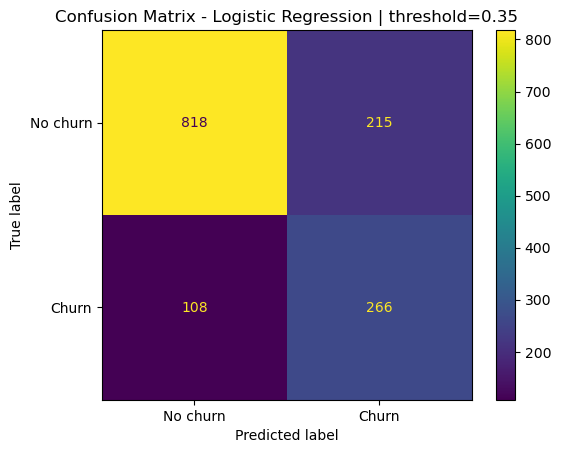

In [32]:
# Confusion matrix at the selected business threshold
selected_pred = (selected_proba >= selected_threshold).astype(int)

cm = confusion_matrix(y_test, selected_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churn"])
disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {selected_model_name} | threshold={selected_threshold:.2f}")
plt.show()

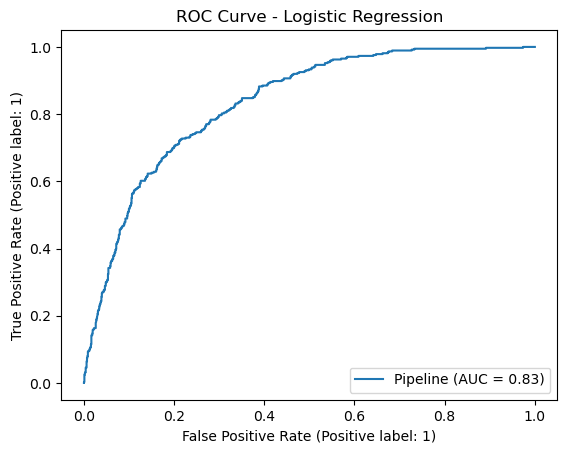

In [33]:
# ROC curve
RocCurveDisplay.from_estimator(selected_model, X_test, y_test)
plt.title(f"ROC Curve - {selected_model_name}")
plt.show()

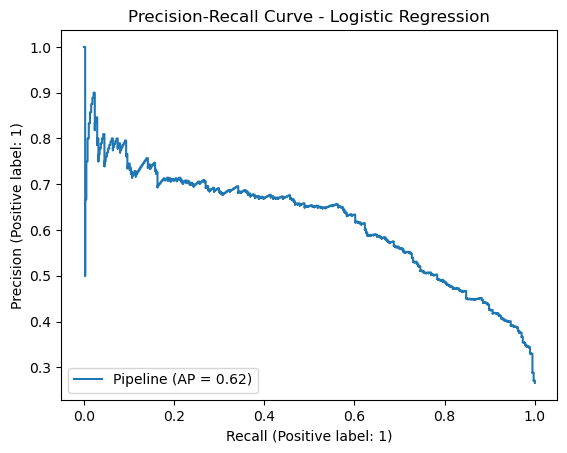

In [34]:
# Precision-Recall curve
PrecisionRecallDisplay.from_estimator(selected_model, X_test, y_test)
plt.title(f"Precision-Recall Curve - {selected_model_name}")
plt.show()

## 15. Error analysis - five worst mistakes

The goal is not only to know the score.  
I want to understand the cases where the model was confidently wrong.

In [35]:
selected_pred = (selected_proba >= selected_threshold).astype(int)

error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["pred"] = selected_pred
error_df["p_churn"] = selected_proba
error_df["is_wrong"] = error_df["y_true"] != error_df["pred"]

# Confident wrong predictions:
# - false negative: real churn, but low predicted churn probability
# - false positive: no churn, but high predicted churn probability
wrong_cases = error_df[error_df["is_wrong"]].copy()
wrong_cases["error_type"] = np.where(wrong_cases["y_true"] == 1, "FN - missed churn", "FP - false alarm")
wrong_cases["wrong_confidence"] = np.where(
    wrong_cases["y_true"] == 1,
    1 - wrong_cases["p_churn"],
    wrong_cases["p_churn"],
)

worst_5 = wrong_cases.sort_values("wrong_confidence", ascending=False).head(5)

cols_to_check = [
    "error_type", "y_true", "pred", "p_churn",
    "tenure", "tenure_group", "Contract", "MonthlyCharges", "TotalCharges",
    "InternetService", "OnlineSecurity", "TechSupport",
    "PaymentMethod", "num_protection_services",
]

available_cols = [c for c in cols_to_check if c in worst_5.columns]
worst_5[available_cols]

,error_type,y_true,pred,p_churn,tenure,Contract,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,TechSupport,PaymentMethod
4378,FN - missed churn,1,0,0.006218,55,Two year,57.55,3046.40,DSL,Yes,Yes,Bank transfer (automatic)
4634,FN - missed churn,1,0,0.011843,65,Two year,74.80,4820.15,DSL,Yes,Yes,Bank transfer (automatic)
2889,FN - missed churn,1,0,0.030675,48,One year,60.35,2896.40,DSL,Yes,Yes,Credit card (automatic)
6858,FN - missed churn,1,0,0.032264,45,One year,54.15,2319.80,DSL,No,Yes,Credit card (automatic)
3827,FN - missed churn,1,0,0.040085,57,One year,70.10,3913.30,DSL,Yes,No,Bank transfer (automatic)


In [36]:
# Summary of all errors
error_summary = (
    error_df[error_df["is_wrong"]]
    .assign(error_type=lambda d: np.where(d["y_true"] == 1, "FN - missed churn", "FP - false alarm"))
    .groupby("error_type")
    .agg(
        count=("error_type", "size"),
        avg_p_churn=("p_churn", "mean"),
        avg_tenure=("tenure", "mean"),
        avg_monthly_charges=("MonthlyCharges", "mean"),
    )
)

error_summary

,count,avg_p_churn,avg_tenure,avg_monthly_charges
error_type,,,,
FN - missed churn,108,0.191677,28.935185,62.929167
FP - false alarm,215,0.539274,15.623256,75.521395


## 16. Feature importance

I use permutation importance to understand which original columns help the selected model rank churn risk.

For feature selection, I calculate the importance on the training set only.  
This avoids using the test set to decide which columns to keep.

In [37]:
# Permutation importance on the training set only
# This is used to choose a smaller feature set without looking at the test labels.
perm = permutation_importance(
    selected_model,
    X_train,
    y_train,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

,feature,importance_mean,importance_std
0,tenure,0.078286,0.006693
1,InternetService,0.043017,0.003677
2,Contract,0.035102,0.004888
3,MonthlyCharges,0.017919,0.001647
4,StreamingTV,0.005327,0.000663
5,StreamingMovies,0.005313,0.000430
6,OnlineSecurity,0.004160,0.001027
7,MultipleLines,0.003759,0.000588
8,TechSupport,0.003093,0.001337
9,PaymentMethod,0.002837,0.000451


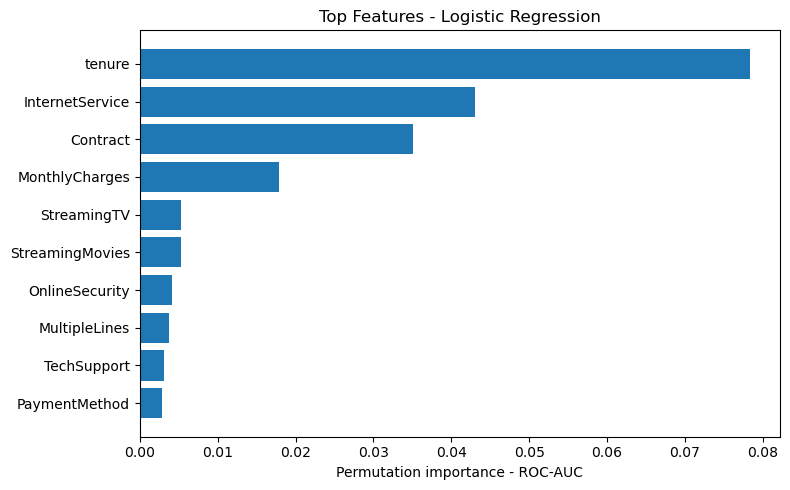

In [38]:
top_importance = importance_df.head(10).sort_values("importance_mean")

plt.figure(figsize=(8, 5))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.xlabel("Permutation importance - ROC-AUC")
plt.title(f"Top Features - {selected_model_name}")
plt.tight_layout()
plt.show()

## 16.1 Top-k feature selection with cross-validation

Instead of choosing `Top 10` automatically, I test several compact feature sets.

The process is:

1. Rank original columns by permutation importance on the training set only.  
2. Test Top 4, Top 6, Top 8, Top 10, and all features using cross-validation on the training set.  
3. Choose the smallest feature set that stays close to the best CV ROC-AUC.

This keeps the test set separate from the feature-selection decision.

In [39]:
# Top-k feature selection using CV on the training set only

ranked_features = importance_df["feature"].tolist()
topk_options = [4, 6, 8, 10, "all"]
topk_results = []
topk_models = {}

def build_logistic_pipeline_for_features(feature_list):
    # Build a Logistic Regression pipeline for a specific list of original columns.
    selected_numeric = [col for col in feature_list if col in numeric_features_model]
    selected_categorical = [col for col in feature_list if col in categorical_features]

    try:
        onehot = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=False)

    numeric_pipe_local = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe_local = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot),
    ])

    preprocess_local = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe_local, selected_numeric),
            ("cat", categorical_pipe_local, selected_categorical),
        ],
        remainder="drop",
    )

    return Pipeline(steps=[
        ("preprocess", preprocess_local),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            C=grid.best_params_["model__C"],
            penalty=grid.best_params_["model__penalty"],
            random_state=RANDOM_STATE,
        )),
    ])

cv_feature_selection = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for k in topk_options:
    if k == "all":
        feature_list = list(X_train.columns)
        label = "All features"
    else:
        feature_list = ranked_features[:k]
        label = f"Top {k}"

    pipe_k = build_logistic_pipeline_for_features(feature_list)

    cv_scores = cross_val_score(
        pipe_k,
        X_train[feature_list],
        y_train,
        scoring="roc_auc",
        cv=cv_feature_selection,
        n_jobs=-1,
    )

    topk_models[label] = {
        "features": feature_list,
        "model": pipe_k,
        "cv_scores": cv_scores,
    }

    topk_results.append({
        "feature_set": label,
        "n_features": len(feature_list),
        "features": ", ".join(feature_list),
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
    })

topk_results_df = (
    pd.DataFrame(topk_results)
    .sort_values("cv_roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)

topk_results_df

,feature_set,n_features,features,cv_roc_auc_mean,cv_roc_auc_std
0,All features,19,"gender, SeniorCitizen, Partner, Dependents, te...",0.844738,0.005487
1,Top 10,10,"tenure, InternetService, Contract, MonthlyChar...",0.844689,0.004691
2,Top 8,8,"tenure, InternetService, Contract, MonthlyChar...",0.842902,0.003707
3,Top 6,6,"tenure, InternetService, Contract, MonthlyChar...",0.839270,0.004427
4,Top 4,4,"tenure, InternetService, Contract, MonthlyCharges",0.834252,0.005525


In [40]:
# Choose the smallest feature set that is close to the best CV score

best_cv_score = topk_results_df["cv_roc_auc_mean"].max()
close_margin = 0.005

eligible_topk = topk_results_df[
    topk_results_df["cv_roc_auc_mean"] >= best_cv_score - close_margin
].copy()

# Prefer fewer original columns when the performance is close
selected_topk_row = (
    eligible_topk
    .sort_values(["n_features", "cv_roc_auc_mean"], ascending=[True, False])
    .iloc[0]
)

selected_feature_set_name = selected_topk_row["feature_set"]
selected_compact_features = topk_models[selected_feature_set_name]["features"]

print("Best CV ROC-AUC:", round(best_cv_score, 4))
print("Selected compact feature set:", selected_feature_set_name)
print("Selected features:")
for feature in selected_compact_features:
    print("-", feature)

Best CV ROC-AUC: 0.8447
Selected compact feature set: Top 8
Selected features:
- tenure
- InternetService
- Contract
- MonthlyCharges
- StreamingTV
- StreamingMovies
- OnlineSecurity
- MultipleLines


In [41]:
# Fit the selected compact model on the full training set and evaluate once on the test set

selected_compact_model = build_logistic_pipeline_for_features(selected_compact_features)
selected_compact_model.fit(X_train[selected_compact_features], y_train)

compact_vs_full = pd.DataFrame([
    evaluate_classifier(
        "Full selected model",
        selected_model,
        X_test,
        y_test,
        threshold=selected_threshold,
    ),
    evaluate_classifier(
        f"Compact Logistic Regression ({selected_feature_set_name})",
        selected_compact_model,
        X_test[selected_compact_features],
        y_test,
        threshold=selected_threshold,
    ),
])

compact_vs_full

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Full selected model,0.35,0.770434,0.553015,0.71123,0.622222,0.833483,0.617386
1,Compact Logistic Regression (Top 8),0.35,0.761905,0.539554,0.71123,0.613610,0.829852,0.608844


## 17. Stability and bias-variance check

I run cross-validation on the selected model and report ROC-AUC mean ± standard deviation directly.  
I also check train-test ROC-AUC gaps for the model families. This helps detect overfitting, especially in tree-based models.

In [42]:
selected_cv_scores = cross_validate(
    selected_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
        "recall": "recall",
        "precision": "precision",
        "f1": "f1",
    },
    n_jobs=-1,
    return_train_score=True,
)

selected_cv_summary = pd.DataFrame({
    "metric": ["ROC-AUC", "PR-AUC", "Recall at 0.5", "Precision at 0.5", "F1 at 0.5"],
    "cv_mean": [
        selected_cv_scores["test_roc_auc"].mean(),
        selected_cv_scores["test_average_precision"].mean(),
        selected_cv_scores["test_recall"].mean(),
        selected_cv_scores["test_precision"].mean(),
        selected_cv_scores["test_f1"].mean(),
    ],
    "cv_std": [
        selected_cv_scores["test_roc_auc"].std(),
        selected_cv_scores["test_average_precision"].std(),
        selected_cv_scores["test_recall"].std(),
        selected_cv_scores["test_precision"].std(),
        selected_cv_scores["test_f1"].std(),
    ],
})

selected_cv_summary

,metric,cv_mean,cv_std
0,ROC-AUC,0.844679,0.005678
1,PR-AUC,0.658327,0.013844
2,Recall at 0.5,0.538462,0.022683
3,Precision at 0.5,0.653004,0.029156
4,F1 at 0.5,0.589960,0.022084


In [43]:
train_scores = evaluate_classifier(selected_model_name + " - train", selected_model, X_train, y_train, threshold=selected_threshold)
test_scores = evaluate_classifier(selected_model_name + " - test", selected_model, X_test, y_test, threshold=selected_threshold)

train_test_gap = pd.DataFrame([train_scores, test_scores])
train_test_gap

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression - train,0.35,0.782044,0.572585,0.709699,0.633811,0.848725,0.666479
1,Logistic Regression - test,0.35,0.770434,0.553015,0.711230,0.622222,0.833483,0.617386


## 18. Generate REPORT.md

This cell creates a first draft of `REPORT_Telco_Churn.md` using the actual notebook results.  
Read it, adjust wording if needed, and keep it in your own style.

In [44]:
# Prepare numbers for the report
selected_flagged_share = selected_pred.mean()

selected_row_05 = test_results[test_results["model"] == selected_model_name].iloc[0]
baseline_row = test_results[test_results["model"] == "Dummy baseline"].iloc[0]

top_features = importance_df.head(5)["feature"].tolist()
top_features_text = ", ".join(top_features[:3])

results_md = test_results.copy()
for col in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
    results_md[col] = results_md[col].map(lambda x: f"{x:.3f}")

try:
    results_table_md = results_md.to_markdown(index=False)
except Exception:
    results_table_md = results_md.to_string(index=False)

roc_auc_cv_mean = selected_cv_summary.loc[
    selected_cv_summary["metric"] == "ROC-AUC", "cv_mean"
].iloc[0]
roc_auc_cv_std = selected_cv_summary.loc[
    selected_cv_summary["metric"] == "ROC-AUC", "cv_std"
].iloc[0]


selected_gap_row = gap_table[gap_table["model"] == selected_model_name]
selected_gap = (
    selected_gap_row["train_test_gap"].iloc[0]
    if len(selected_gap_row) > 0
    else np.nan
)

rf_gap_row = gap_table[gap_table["model"].str.contains("Random Forest", regex=False)].head(1)
rf_gap = (
    rf_gap_row["train_test_gap"].iloc[0]
    if len(rf_gap_row) > 0
    else np.nan
)

gb_gap_row = gap_table[gap_table["model"].str.contains("Gradient Boosting", regex=False)].head(1)
gb_gap = (
    gb_gap_row["train_test_gap"].iloc[0]
    if len(gb_gap_row) > 0
    else np.nan
)

tuning_summary_report = tuning_summary.copy()
tuning_summary_report["best_cv_roc_auc"] = tuning_summary_report["best_cv_roc_auc"].map(lambda x: f"{x:.4f}")
tuning_summary_report["best_params"] = tuning_summary_report["best_params"].map(str)

try:
    tuning_summary_md = tuning_summary_report.to_markdown(index=False)
except Exception:
    tuning_summary_md = tuning_summary_report.to_string(index=False)


selected_compact_features_text = ", ".join(selected_compact_features)

compact_test_row = compact_vs_full[
    compact_vs_full["model"].str.contains("Compact Logistic Regression", regex=False)
].iloc[0]

full_selected_row = compact_vs_full[
    compact_vs_full["model"] == "Full selected model"
].iloc[0]

topk_results_report = topk_results_df.copy()
topk_results_report["cv_roc_auc_mean"] = topk_results_report["cv_roc_auc_mean"].map(lambda x: f"{x:.4f}")
topk_results_report["cv_roc_auc_std"] = topk_results_report["cv_roc_auc_std"].map(lambda x: f"{x:.4f}")

try:
    topk_results_md = topk_results_report.to_markdown(index=False)
except Exception:
    topk_results_md = topk_results_report.to_string(index=False)
report_text = f"""# REPORT.md - Telco Customer Churn Classification

**Student:** Netanel Farhi  
**Task:** Option B - Telco Customer Churn Classification  
**Dataset:** Telco Customer Churn, Kaggle  

---

## 1. Business framing

The business problem is customer churn prediction.  
The company wants to identify customers who are likely to leave, so the retention team can focus on the right customers before it is too late.

**Target:** `Churn = Yes`  
**Positive class:** churn customer  
**Model-selection metric:** ROC-AUC  
**Operating metric:** recall / precision at the selected threshold

I selected the model by ROC-AUC because it measures how well the model ranks churn risk across thresholds.  
After choosing the model, I selected the threshold with cross-validation on the training set, based on the tradeoff between missing churn customers and contacting extra customers.

---

## 2. Data preparation

I started with data type checks, missing values, duplicate rows, duplicate customer IDs, unique values, and target distribution.  
`TotalCharges` was stored as text, so I converted it to numeric. This created {rows_before - rows_after} missing rows, which I removed because the amount was very small.  
I kept `SeniorCitizen` as a binary 0/1 feature because it was already a valid indicator.

---

## 3. EDA and data validation

I checked impossible values such as negative tenure, negative monthly charges, negative total charges, and invalid `SeniorCitizen` values.  
The EDA showed that churn is higher for newer customers, month-to-month contracts, and customers with higher monthly charges.

---

## 4. Results table

{results_table_md}

**Selected model:** {selected_model_name}  

I selected by ROC-AUC. The models were close, so I preferred the simpler Logistic Regression when the gap was small.  
The selected model achieved ROC-AUC of {selected_row_05["roc_auc"]:.3f} on the test set, compared with the dummy baseline ROC-AUC of {baseline_row["roc_auc"]:.3f}.\n\nThe real models are close to each other, around the same ROC-AUC range. Because the score is already stable, I kept the tuning limited and focused on a clear threshold decision instead of adding many more models.

---

## 4.1 Train-test gap

The selected model train-test ROC-AUC gap was {selected_gap:.3f}.  
For the tree-based models, I checked the train-test gap because these models can overfit more easily.  
Random Forest used `min_samples_leaf=5`. Gradient Boosting used smaller trees, a lower learning rate, subsampling, and more estimators.


## 4.2 Hyperparameter tuning

I tuned Logistic Regression with GridSearchCV.  
I also used a small RandomizedSearchCV for Random Forest and Gradient Boosting.  
The goal was to check a few reasonable settings without making the search unnecessarily large.

{tuning_summary_md}

## 4.3 Feature selection

To avoid choosing an arbitrary number of features, I ranked the original columns by permutation importance on the training set, then compared Top 4, Top 6, Top 8, Top 10, and all features using cross-validation.

{topk_results_md}

I selected `{selected_feature_set_name}` because it gave a simpler model while staying close to the best CV ROC-AUC.  
The selected compact features were: {selected_compact_features_text}.

At the selected threshold, the compact model achieved recall {compact_test_row["recall"]:.3f}, precision {compact_test_row["precision"]:.3f}, F1 {compact_test_row["f1"]:.3f}, and ROC-AUC {compact_test_row["roc_auc"]:.3f}.  
The full selected model achieved recall {full_selected_row["recall"]:.3f}, precision {full_selected_row["precision"]:.3f}, F1 {full_selected_row["f1"]:.3f}, and ROC-AUC {full_selected_row["roc_auc"]:.3f}.

This comparison shows the tradeoff between a simpler model and the small loss in performance.

## 5. Threshold decision

I selected the operating threshold using cross-validation on the training set, not by searching directly on the test set.  
{threshold_selection_note}

On the test set, threshold {selected_threshold:.2f} flags {selected_flagged_share:.1%} of customers.  
At this threshold, recall is {selected_metrics["recall"]:.3f} and precision is {selected_metrics["precision"]:.3f}.  
The approximate 95% band around recall is ±{recall_ci_95:.3f}, based on {n_positive_test} positive test cases.

---

## 6. Guiding questions

### 1. Accuracy trap

Accuracy is misleading here because the dummy baseline already reaches accuracy of {baseline_row["accuracy"]:.3f} by predicting that nobody churns.  
The selected model accuracy at the selected threshold is {selected_metrics["accuracy"]:.3f}, which can be lower than the dummy, but it catches real churn customers.  
That is the accuracy trap: higher accuracy does not mean the model solves the business problem.

### 2. Cost of mistakes

A false positive means the company may contact or offer a retention action to a customer who would have stayed.  
A false negative means the company misses a customer who is actually about to leave.  
I used a cross-validation threshold table on the training set to choose the operating point: lower thresholds catch more churn customers, while higher thresholds reduce unnecessary contacts.

### 3. Is it worth deploying?

The model lifts ROC-AUC from {baseline_row["roc_auc"]:.2f} for the dummy baseline to about {selected_row_05["roc_auc"]:.2f}.  
The models were close, so I would not choose a more complex model unless it gives a clear business improvement.  
I would use the selected model as a prioritization tool, not as an automatic decision engine.

### 4. What drives the model?

The strongest features by permutation importance were {top_features_text}.  
These features make business sense because churn is strongly connected to contract type, tenure, service usage, and billing behavior.  
I also compared compact feature sets with cross-validation to check whether fewer columns could keep similar performance.

### 5. Worst mistakes

The worst mistakes are the cases where the model was confident but wrong.  
A typical pattern is long-tenure customers on one-year or two-year contracts who churned anyway, and some high-risk month-to-month customers who stayed.  
These are hard cases because their behavior goes against the main pattern in the data.

### 6. Stability

The selected model ROC-AUC across CV folds was {roc_auc_cv_mean:.3f} ± {roc_auc_cv_std:.3f}.  
I would report the mean and standard deviation together, not a single number.  
This is more honest for stakeholders and avoids over-promising.

### 7. Leakage and split

For this dataset, there is no date column, so I used a stratified train-test split.  
All preprocessing was inside sklearn pipelines, so the test data did not influence imputation, scaling, encoding, or model fitting.  
I removed `customerID` and the raw target column before modeling.

### 8. Production mindset

If this model went live, I would monitor ROC-AUC, recall, precision, false negatives, churn rate, calibration, and feature drift.  
I would retrain the model if the customer mix, pricing, contracts, or churn rate changed materially.  
The model should support retention prioritization, not make customer decisions alone.

---

## 7. Model Card

### Overview
- Task: Predict customer churn.
- Dataset: Telco Customer Churn.
- Target: `Churn = Yes`.
- Positive class: churn.

### Metric and performance
- Model-selection metric: ROC-AUC.
- Operating threshold: {selected_threshold:.2f}, selected using cross-validation on the training set.
- Selected model: {selected_model_name}.
- Test ROC-AUC: {selected_row_05["roc_auc"]:.3f}.
- Test recall at selected threshold: {selected_metrics["recall"]:.3f}.
- Test precision at selected threshold: {selected_metrics["precision"]:.3f}.

### What the model relies on
- Top features: {", ".join(top_features)}.\n- Compact feature-set selected by CV: {selected_feature_set_name} — {selected_compact_features_text}.
- Leakage check: removed `customerID`, target not included in features, preprocessing inside pipeline.
- Multicollinearity check: numeric correlation and VIF-like check on training data only.

### Limitations and failure modes
- The dataset is historical and may not represent future churn behavior.
- The model may over-prioritize some customer groups if the business process changes.
- Probability calibration should be monitored if the model is deployed.

### Real world use
The model should be used as a decision-support tool.  
Recommended use: rank customers by churn risk and let the retention team review the list.

### Monitoring
Monitor ROC-AUC, recall, precision, false negatives, churn rate, probability calibration, feature drift, and offer acceptance rate.  
Retrain if performance drops or if the business process changes.
"""

report_text = textwrap.dedent(report_text)
report_path = Path("REPORT_Telco_Churn.md")
report_path.write_text(report_text, encoding="utf-8")

print(f"Report saved to: {report_path.resolve()}")
print(report_text[:1500])

Report saved to: C:\Users\netaf\MATALOT BIU\REPORT_Telco_Churn.md
# REPORT.md - Telco Customer Churn Classification

**Student:** Netanel Farhi  
**Task:** Option B - Telco Customer Churn Classification  
**Dataset:** Telco Customer Churn, Kaggle  

---

## 1. Business framing

The business problem is customer churn prediction.  
The company wants to identify customers who are likely to leave, so the retention team can focus on the right customers before it is too late.

**Target:** `Churn = Yes`  
**Positive class:** churn customer  
**Model-selection metric:** ROC-AUC  
**Operating metric:** recall / precision at the selected threshold

I selected the model by ROC-AUC because it measures how well the model ranks churn risk across thresholds.  
After choosing the model, I selected the threshold with cross-validation on the training set, based on the tradeoff between missing churn customers and contacting extra customers.

---

## 2. Data preparation

I started with data type checks, m